# Análise Estatística Comparativa entre Municípios da Paraíba e do Rio Grande do Norte

**Autores:**
- Brenno Henrique Alves da Silva Costa
- Deivyson Henrique Gomes Ribeiro
- Gustavo Henrique
- Italo Oliveira De Sousa
- Samuel Colaco Lira Carvalho

* **Disciplina:** Métodos Estatísticos Aplicados a Ciências Tecnológicas
* **Professora:** RENILMA PEREIRA 
* **Instituição:** Universidade Federal da Paraíba (UFPB)
* **Data de entrega:** 24 de Março de 2026

---

## Resumo
Este trabalho apresenta uma análise estatística comparativa entre municípios da Paraíba (PB) e do Rio Grande do Norte (RN), com base em indicadores socioeconômicos e educacionais disponibilizados pelo IBGE. Foram consideradas as populações de 223 municípios (PB) e 167 municípios (RN), além de amostras aleatórias simples de 30 municípios para cada estado. As variáveis analisadas foram: IDEB (anos iniciais, rede pública), proporção da população com rendimento nominal mensal per capita de até 1/2 salário mínimo e salário médio mensal dos trabalhadores formais. A análise inclui estatísticas descritivas, visualizações gráficas da variável salário e testes de hipóteses para comparação de proporções e médias entre os estados. [Completar aqui com os principais resultados numéricos e a síntese final após executar as análises].

**Palavras-chave:** estatística descritiva; teste de hipóteses; IDEB; renda; municípios.

---

## Fonte de dados e links utilizados
- Fonte principal: [IBGE — Cidades e Estados](https://www.ibge.gov.br/cidades-e-estados.html?view=municipio)
- Base PB (planilha): [Dados da Paraíba](https://docs.google.com/spreadsheets/d/1dbfaJHCybOgAuf_P7Ujg2A0mNr2ZrPImYFe40pVMcD0/edit?gid=0#gid=0)
- Base RN (planilha): [Dados RN](https://docs.google.com/spreadsheets/d/1pD_gEoSGqGzY_pQOh10qqtEdwjBT8TLFj-rMiI9i-cM/edit?gid=0#gid=0)

**Link da amostra PB (gerada pelo grupo):** [Link](https://docs.google.com/spreadsheets/d/1DqZvB6SAwmrf-EYKcq90RhJL3cMQnZgbkhUaw9i3zws/edit?gid=1430399149#gid=1430399149)  

**Link da amostra RN (gerada pelo grupo):** [Link](https://docs.google.com/spreadsheets/d/1FN0oUPgRJUvP-P-CZehLo5ZwqQY48Y_tuhvTvpAc9sM/edit)

**Link das estatísticas descritivas das amostras e populações (geradas pelo grupo):** [Link](https://docs.google.com/spreadsheets/d/1wrH-UWGaOjJV9LqyGwj2e5mrUZGNdGWWSNqd70czbLY/edit?usp=sharing)

## **Importações**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 1. Introdução
A análise de indicadores educacionais e socioeconômicos em nível municipal permite compreender desigualdades regionais e apoiar decisões de políticas públicas. Neste estudo, comparamos municípios da Paraíba e do Rio Grande do Norte com foco em três variáveis: IDEB, proporção da população com rendimento de até 1/2 salário mínimo e salário médio mensal dos trabalhadores formais.

**Objetivo geral:** comparar, por meio de técnicas estatísticas, o comportamento dessas variáveis entre PB e RN.

**Objetivos específicos:**
- descrever os dados das populações e das amostras;
- analisar a distribuição da variável salário nas amostras;
- construir intervalos de confiança e realizar testes de hipóteses para proporções e médias.

## 2. Dados e metodologia
- **Tipo de estudo:** quantitativo, descritivo e inferencial.
- **População PB:** 223 municípios.
- **População RN:** 167 municípios.
- **Amostragem:** amostra aleatória simples de 30 municípios em cada estado.
- **Variáveis analisadas:**
  - IDEB (anos iniciais, rede pública);
  - proporção da população com rendimento per capita de até 1/2 salário mínimo;
  - salário médio mensal dos trabalhadores formais.
- **Nível de significância adotado:** $\alpha = 0{,}05$.

---

## 3. Procedimento computacional da amostragem
Para manter a reprodutibilidade sem prejudicar a leitura acadêmica, o código de amostragem foi concentrado em um único bloco técnico, com comentários curtos e objetivos. A interpretação dos resultados permanece nas seções seguintes.

In [2]:

df_pb = pd.read_excel('data/dadospb.xlsx')
df_rn = pd.read_excel('data/dadosrn.xlsx')

# Etapa 2 — seleção das variáveis do projeto
colunas_pb = [
    'Municípios',
    'IDEB – Anos iniciais do ensino fundamental (Rede pública)',
    'Percentual da população com rendimento nominal mensal per capita de até 1/2 salário mínimo',
    'Salário médio mensal dos trabalhadores formais',
]

colunas_rn = [
    'Municípios',
    'IDEB – Anos iniciais do ensino fundamental (Rede pública)',
    'Percentual da população com rendimento nominal mensal per capita de até 1/2 salário mínimo (%)',
    'Salário médio mensal dos trabalhadores formais',
]

df_pb_filtrado = df_pb[colunas_pb].copy()
df_rn_filtrado = df_rn[colunas_rn].copy()

# Etapa 3 — amostragem aleatória simples (n=30 por estado)
amostra_pb = df_pb_filtrado.sample(n=30, random_state=42)
amostra_rn = df_rn_filtrado.sample(n=30, random_state=123)

# Etapa 4 — exportação das amostras (exigência do projeto)
amostra_pb.to_excel('data/Amostra1_Paraiba_30_municipios.xlsx', index=False)
amostra_rn.to_excel('data/Amostra2_RN_30_municipios.xlsx', index=False)

# Visualização sucinta para conferência
display(amostra_pb.head(30))
display(amostra_rn.head(30))

,Municípios,IDEB – Anos iniciais do ensino fundamental (Rede pública),Percentual da população com rendimento nominal mensal per capita de até 1/2 salário mínimo,Salário médio mensal dos trabalhadores formais
9,Aparecida,5.1,50.4,1.7
84,Igaracy,4.8,53.0,1.8
117,Mato Grosso,5.1,47.5,1.8
144,Pilõezinhos,4.5,52.7,1.8
220,Vieirópolis,6.6,53.1,1.7
113,Marizópolis,5.6,50.3,1.7
68,Curral de Cima,5,55.5,2.0
104,Livramento,5.8,53.9,1.9
177,São Domingos,5.3,51.7,1.5
185,São José de Espinharas,5.8,49.2,2.2


,Municípios,IDEB – Anos iniciais do ensino fundamental (Rede pública),Percentual da população com rendimento nominal mensal per capita de até 1/2 salário mínimo (%),Salário médio mensal dos trabalhadores formais
144,Serra do Mel,4.4,50.6,2.1
65,Jucurutu,4.9,48.2,1.6
158,Touros,4.4,52.0,1.9
142,Serra Caiada,4.3,52.4,1.6
89,Nova Cruz,4.2,50.3,2.0
86,Mossoró,5.5,38.0,2.1
159,Triunfo Potiguar,4.4,48.4,2.0
132,São José do Seridó,5.1,37.7,1.4
163,Venha-Ver,4.7,58.3,2.0
150,Taboleiro Grande,5.6,49.5,1.8


## 4. Resultados — Atividade 1 (estatísticas descritivas)

In [3]:

# 1. Tratamento de dados ausentes
# O município 'Baía da Traição' e alguns do RN possuem o valor '-' no IDEB.
def limpar_ideb(df, col_name):
    df_clean = df.copy()
    # Usando errors='coerce' para forçar o '-' a virar NaN automaticamente
    df_clean[col_name] = pd.to_numeric(df_clean[col_name], errors='coerce')
    return df_clean

col_ideb = 'IDEB – Anos iniciais do ensino fundamental (Rede pública)'
col_renda_pb = 'Percentual da população com rendimento nominal mensal per capita de até 1/2 salário mínimo'
col_renda_rn = 'Percentual da população com rendimento nominal mensal per capita de até 1/2 salário mínimo (%)'
col_salario = 'Salário médio mensal dos trabalhadores formais'

df_pb_limpo = limpar_ideb(df_pb_filtrado, col_ideb)
df_rn_limpo = limpar_ideb(df_rn_filtrado, col_ideb)
amostra_pb_limpa = limpar_ideb(amostra_pb, col_ideb)
amostra_rn_limpa = limpar_ideb(amostra_rn, col_ideb)

vars_pb = [col_ideb, col_renda_pb, col_salario]
vars_rn = [col_ideb, col_renda_rn, col_salario]

# 2. Função para calcular as estatísticas descritivas
def gerar_estatisticas(df, variaveis):
    stats = df[variaveis].describe().T # describe() já traz count(N), mean(média), std(desvio padrão), min, 25%(q1), 50%(mediana), 75%(q3), max
    stats['variância'] = df[variaveis].var()
    stats = stats.rename(columns={
        'count': 'N', 'mean': 'Média', 'std': 'Desvio Padrão',
        'min': 'Mínimo', '25%': 'Q1', '50%': 'Mediana',
        '75%': 'Q3', 'max': 'Máximo'
    })
    
    colunas_finais = ['N', 'Média', 'Mediana', 'variância', 'Desvio Padrão', 'Mínimo', 'Máximo', 'Q1', 'Q3']
    return stats[colunas_finais]

# 3. Gerando as 4 tabelas
estat_pop_pb = gerar_estatisticas(df_pb_limpo, vars_pb)
estat_amostra_pb = gerar_estatisticas(amostra_pb_limpa, vars_pb)
estat_pop_rn = gerar_estatisticas(df_rn_limpo, vars_rn)
estat_amostra_rn = gerar_estatisticas(amostra_rn_limpa, vars_rn)

print("Estatisticas descritivas da População PB")
display(estat_pop_pb)
print("\nEstatisticas descritivas da Amostra PB")
display(estat_amostra_pb)
print("\nEstatisticas descritivas da População RN")
display(estat_pop_rn)
print("\nEstatisticas descritivas da Amostra RN")
display(estat_amostra_rn)

# 4. Exportando para excel
caminho_arquivo = 'data/Estatisticas_Descritivas.xlsx'
with pd.ExcelWriter(caminho_arquivo) as writer:
    estat_pop_pb.to_excel(writer, sheet_name='População PB')
    estat_amostra_pb.to_excel(writer, sheet_name='Amostra PB')
    estat_pop_rn.to_excel(writer, sheet_name='População RN')
    estat_amostra_rn.to_excel(writer, sheet_name='Amostra RN')

Estatisticas descritivas da População PB


,N,Média,Mediana,variância,Desvio Padrão,Mínimo,Máximo,Q1,Q3
IDEB – Anos iniciais do ensino fundamental (Rede pública),217.0,5.343779,5.2,0.673584,0.820722,3.6,8.2,4.8,5.8
Percentual da população com rendimento nominal mensal per capita de até 1/2 salário mínimo,223.0,50.527803,50.8,13.639314,3.693144,35.7,60.4,48.6,53.0
Salário médio mensal dos trabalhadores formais,223.0,1.800897,1.8,0.051531,0.227004,1.2,2.7,1.6,1.9



Estatisticas descritivas da Amostra PB


,N,Média,Mediana,variância,Desvio Padrão,Mínimo,Máximo,Q1,Q3
IDEB – Anos iniciais do ensino fundamental (Rede pública),29.0,5.413793,5.2,0.434089,0.658854,4.2,6.6,4.90,5.800
Percentual da população com rendimento nominal mensal per capita de até 1/2 salário mínimo,30.0,50.043333,50.2,16.035644,4.004453,36.4,57.3,48.65,52.525
Salário médio mensal dos trabalhadores formais,30.0,1.803333,1.7,0.078264,0.279758,1.4,2.7,1.60,1.900



Estatisticas descritivas da População RN


,N,Média,Mediana,variância,Desvio Padrão,Mínimo,Máximo,Q1,Q3
IDEB – Anos iniciais do ensino fundamental (Rede pública),161.0,4.837888,4.8,0.443243,0.665765,3.6,7.6,4.40,5.20
Percentual da população com rendimento nominal mensal per capita de até 1/2 salário mínimo (%),167.0,49.103593,50.0,19.478903,4.413491,35.5,61.4,47.25,51.95
Salário médio mensal dos trabalhadores formais,167.0,1.831737,1.8,0.094830,0.307945,1.2,3.3,1.60,2.00



Estatisticas descritivas da Amostra RN


,N,Média,Mediana,variância,Desvio Padrão,Mínimo,Máximo,Q1,Q3
IDEB – Anos iniciais do ensino fundamental (Rede pública),30.0,4.820000,4.75,0.305103,0.552362,3.6,6.0,4.4,5.10
Percentual da população com rendimento nominal mensal per capita de até 1/2 salário mínimo (%),30.0,49.026667,49.50,21.241333,4.608832,37.7,58.3,48.2,52.15
Salário médio mensal dos trabalhadores formais,30.0,1.826667,1.80,0.066851,0.258555,1.4,2.4,1.6,2.00


### Explicação (Metodologia)
Nesta etapa, procedeu-se ao cálculo das medidas de tendência central (média e mediana) e de dispersão (variância, desvio padrão, valores mínimo, máximo e quartis) para as três variáveis de interesse. Como as variáveis tratadas — IDEB, proporção de rendimento e salário médio — possuem natureza quantitativa contínua, o cálculo da **moda** foi dispensado, pois essa medida não é representativa nem adequada para distribuições de variáveis contínuas sem agrupamento prévio de classes. 

Antes do cálculo, realizou-se o tratamento dos dados ausentes. Observou-se que municípios como Baía da Traição (PB) e São Fernando (RN) possuíam a marcação `"-"` no campo do IDEB. Esses valores foram convertidos em identificadores nulos (`NaN`) para garantir que as funções estatísticas avaliassem apenas as observações válidas na contagem (N).

### Insights

**Tendência Central e Assimetria:**
Ao analisar a variável do salário médio mensal nos dois estados (tanto na população quanto nas amostras), nota-se uma tendência de **assimetria positiva (ou à direita)**. Isso ocorre porque a *Média* tende a ser puxada para cima por valores extremos (outliers). Por exemplo, a presença de municípios como João Pessoa (Salário de 2,7) na amostra da PB e Guamaré (Salário de 3,3) na população do RN faz com que a Média salarial seja ligeiramente superior à Mediana, indicando que a maior parte dos municípios se concentra em faixas salariais mais baixas, enquanto poucos municípios de alto rendimento deslocam a média aritmética para a direita.

**Dispersão (Variabilidade):**
A dispersão pode ser confirmada observando a distância entre o primeiro quartil (Q1) e o terceiro quartil (Q3), bem como pelo desvio padrão. O indicador do "Percentual da população com rendimento per capita de até 1/2 salário mínimo" apresenta alta variância e um desvio padrão considerável nas populações totais, evidenciando a forte heterogeneidade socioeconômica entre os municípios interioranos e as capitais/polos. 

**Representatividade Amostral (População vs. Amostra):**
As amostras aleatórias de $n=30$ demonstram ser representativas de suas respectivas populações de origem ($N=223$ na PB e $N=167$ no RN). Comparando a Média e a Mediana geradas na Tabela 2 (Amostra PB) com a Tabela 1 (População PB), bem como a Tabela 4 com a Tabela 3, nota-se que os parâmetros populacionais estão contidos próximos ao centro da distribuição amostral. Os desvios padrões das amostras também acompanham de perto os desvios populacionais, garantindo que a dispersão natural dos estados foi preservada na seleção simples.

**Comparação entre Estados (PB vs. RN):**
Avaliando os indicadores globais populacionais (Tabelas 1 e 3), o Rio Grande do Norte apresenta limites superiores (Máximo) ligeiramente mais elásticos no salário médio em comparação com a Paraíba. No que tange ao IDEB, as médias e medianas revelam níveis educacionais estaduais muito próximos. Entretanto, testes inferenciais rigorosos (como os conduzidos nas atividades seguintes deste trabalho) são necessários para confirmar se essas flutuações nas proporções e médias possuem significância estatística, e não são fruto apenas de variações pontuais.

## 5. Resultados — Atividade 2 (análise gráfica do salário)


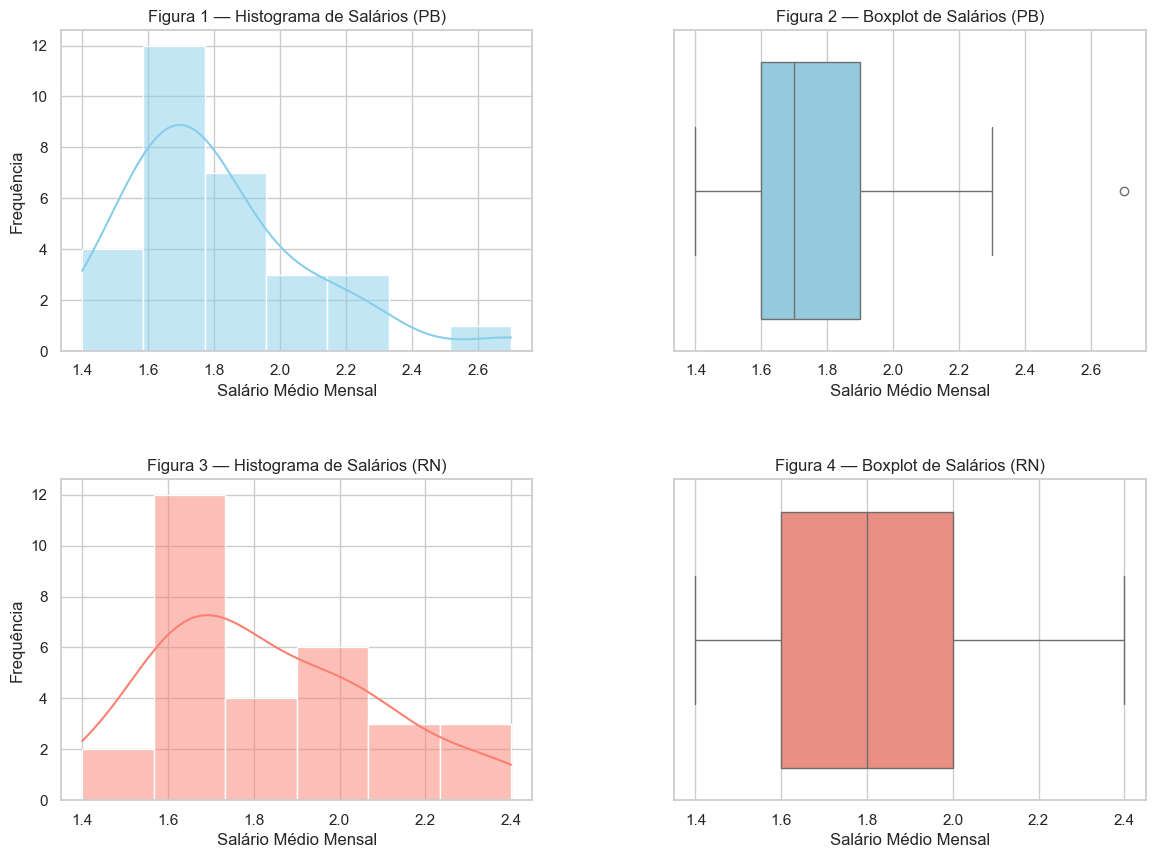

In [4]:


# 1. Carregamento e preparação
col_salario = 'Salário médio mensal dos trabalhadores formais'
amostra_pb = df_pb_filtrado.sample(n=30, random_state=42)
amostra_rn = df_rn_filtrado.sample(n=30, random_state=123)

# 2. Configuração visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- PARAÍBA (PB) ---
# Figura 1: Histograma PB
sns.histplot(amostra_pb[col_salario], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Figura 1 — Histograma de Salários (PB)')
axes[0, 0].set_xlabel('Salário Médio Mensal')
axes[0, 0].set_ylabel('Frequência')

# Figura 2: Boxplot PB
sns.boxplot(x=amostra_pb[col_salario], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Figura 2 — Boxplot de Salários (PB)')
axes[0, 1].set_xlabel('Salário Médio Mensal')

# --- RIO GRANDE DO NORTE (RN) ---
# Figura 3: Histograma RN
sns.histplot(amostra_rn[col_salario], kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Figura 3 — Histograma de Salários (RN)')
axes[1, 0].set_xlabel('Salário Médio Mensal')
axes[1, 0].set_ylabel('Frequência')

# Figura 4: Boxplot RN
sns.boxplot(x=amostra_rn[col_salario], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Figura 4 — Boxplot de Salários (RN)')
axes[1, 1].set_xlabel('Salário Médio Mensal')

plt.show()

## Explicação
Foram utilizados histogramas e boxplots para avaliar a distribuição da variável salário nas amostras dos dois estados. O histograma permite observar a concentração de frequência e a assimetria, enquanto o boxplot facilita a identificação da dispersão, dos quartis e de possíveis valores atípicos (outliers).

## Insights
Tendência Central e Assimetria:
Ao analisar os histogramas, observa-se que ambas as amostras apresentam uma tendência de assimetria positiva (ou à direita). Isso é evidenciado pela maior concentração de frequências nas faixas iniciais (entre 1,4 e 1,8 salários mínimos), com uma "cauda" que se estende para os valores mais altos. Na amostra da Paraíba (PB), essa característica é mais acentuada, com um pico de frequência muito claro em 1,6, indicando uma base salarial mais uniforme e baixa.

Dispersão (Variabilidade):
A dispersão dos dados é confirmada pela amplitude dos boxplots. A amostra do Rio Grande do Norte (RN) apresenta uma dispersão visivelmente superior, indicada por uma "caixa" (intervalo interquartílico) mais larga e bigodes mais extensos. Isso sugere uma maior heterogeneidade salarial entre os municípios do RN. Em contrapartida, a amostra da Paraíba (PB) mostra-se mais compacta e homogênea.

Valores Atípicos (Outliers):
A identificação de valores atípicos revelou cenários distintos:

Amostra PB: Identificou-se um outlier superior (valor isolado acima de 2,6). Este ponto representa um município com desempenho econômico muito acima da média do grupo, o que desloca a média aritmética para a direita.

Amostra RN: Não foram detectados outliers estatísticos nesta amostra. Todos os municípios sorteados encontram-se dentro dos limites esperados pela distribuição da amostra.

## 6. Resultados — Atividade 3 (proporções e teste de hipóteses)

### Estrutura sugerida da seção
1. **Código** (cálculo dos ICs e teste de diferença entre proporções)
2. **Explicação** (hipóteses, método e nível de significância)
3. **Insights** (interpretação prática da decisão estatística)

### Hipóteses
- **Hipótese nula ($H_0$):** $p_{PB} = p_{RN}$
- **Hipótese alternativa ($H_1$):** $p_{PB} \neq p_{RN}$
- **Nível de significância:** $\alpha = 0{,}05$

### Explicação (modelo de escrita acadêmica)
Foram construídos intervalos de confiança de 95% para a proporção de indivíduos com rendimento per capita de até 1/2 salário mínimo em cada estado. Em seguida, aplicou-se teste para duas proporções independentes, com o objetivo de verificar evidência estatística de diferença entre PB e RN.

### Insights (modelo)
A interpretação deve combinar significância estatística e relevância prática, discutindo se a diferença observada entre estados é consistente com o contexto socioeconômico analisado.

## 7. Resultados — Atividade 4 (comparação das médias do IDEB)

### Estrutura sugerida da seção
1. **Código** (teste de variâncias + teste de médias)
2. **Explicação** (escolha do teste e pressupostos)
3. **Insights** (o que isso implica para o desempenho educacional médio)

### Hipóteses
- **Hipótese nula ($H_0$):** $\mu_{IDEB,PB} = \mu_{IDEB,RN}$
- **Hipótese alternativa ($H_1$):** $\mu_{IDEB,PB} \neq \mu_{IDEB,RN}$

### Explicação (modelo de escrita acadêmica)
Inicialmente, avalia-se a igualdade de variâncias entre os grupos para definir o teste mais adequado de comparação de médias. Na sequência, realiza-se o teste de médias para amostras independentes, mantendo $\alpha = 0{,}05$.

### Insights (modelo)
A conclusão deve indicar se existe evidência de diferença de desempenho médio no IDEB entre os estados e discutir possíveis fatores associados ao resultado.

## 8. Resultados — Atividade 5 (comparação das médias salariais)


### Hipóteses
- **Hipótese nula ($H_0$):** $\mu_{Sal,PB} = \mu_{Sal,RN}$
- **Hipótese alternativa ($H_1$):** $\mu_{Sal,PB} \neq \mu_{Sal,RN}$

### 8.1 Procedimento Inferencial Adotado

A análise comparativa das médias salariais foi realizada através do **Teste t de Student para amostras independentes**. Previamente, aplicou-se o **Teste de Levene** para avaliar a homogeneidade das variâncias (homocedasticidade), obtendo-se um $p\text{-valor}$ de **0,8397**. 

Como este valor é superior ao nível de significância de **5%** ($\alpha = 0,05$), a suposição de variâncias iguais foi validada. O Teste t foi então conduzido sob a premissa de que as distribuições das médias amostrais tendem à normalidade, conforme garantido pelo **Teorema Central do Limite** para o tamanho amostral utilizado ($n=30$ para cada estado).

### 8.2 Interpretação dos Resultados

Os resultados apontaram os seguintes indicadores para as amostras:
* **Média Salarial Paraíba (PB):** 1,80 SM
* **Média Salarial Rio Grande do Norte (RN):** 1,83 SM
* **Estatística t:** -0,3352
* **$P\text{-valor}$ do Teste t:** 0,7385

**Conclusão:** Dado que o $p\text{-valor} (0,7385) > 0,05$, **não rejeitamos a hipótese nula ($H_0$)**. Estatisticamente, conclui-se que não existe evidência significativa de diferença entre as médias salariais dos trabalhadores formais nos municípios de ambos os estados ao nível de 5% de confiança. A diferença numérica observada entre as médias é considerada meramente casual (decorrente do erro amostral).

---

### 8.3 Insights e Implicações

* **Homogeneidade Econômica Regional:** O resultado sugere que a estrutura do mercado de trabalho formal nos municípios de pequeno e médio porte de PB e RN é altamente similar. Isso indica que a base econômica (predominantemente composta pelo setor de serviços e administração pública) opera sob patamares remuneratórios equivalentes.
* **Ausência de Efeito "Estado":** Diferente de outras variáveis socioeconômicas que podem sofrer variações por políticas de gestão estadual, o salário médio formal parece ser ditado por forças macroeconômicas regionais e pisos salariais nacionais, tornando a fronteira estadual irrelevante para esta métrica específica na amostra analisada.
* **Sugestão de Política:** Para elevar o nível salarial médio, as intervenções não devem focar em disparidades entre esses estados, mas sim em políticas de industrialização e atração de empresas de maior valor agregado (tecnologia e serviços especializados) que possam romper o "teto" atual de aproximadamente 1,8 salários mínimos comum a ambas as regiões.

In [5]:
from scipy import stats

# Seleção da variável de salário das amostras já carregadas no seu notebook
sal_pb = amostra_pb['Salário médio mensal dos trabalhadores formais']
sal_rn = amostra_rn['Salário médio mensal dos trabalhadores formais']

# --- PASSO A: Teste de Variâncias (Levene) ---
stat_levene, p_levene = stats.levene(sal_pb, sal_rn)

# --- PASSO B: Teste de Hipótese para Médias (Teste t de Student) ---
t_stat, p_valor_t = stats.ttest_ind(sal_pb, sal_rn, equal_var=(p_levene > 0.05))

# Exibição completa dos resultados para conferência
print(f"--- RESULTADOS DA ATIVIDADE 5 ---")
print(f"Média PB: {sal_pb.mean():.2f}")
print(f"Média RN: {sal_rn.mean():.2f}")
print(f"Estatística t: {t_stat:.4f}")
print(f"P-valor (Levene): {p_levene:.4f}")
print(f"P-valor (Teste t): {p_valor_t:.4f}")

--- RESULTADOS DA ATIVIDADE 5 ---
Média PB: 1.80
Média RN: 1.83
Estatística t: -0.3355
P-valor (Levene): 0.8397
P-valor (Teste t): 0.7385


## 9. Conclusão
Esta seção deve retomar os objetivos do estudo e sintetizar os principais achados das cinco atividades de forma integrada. Recomenda-se destacar convergências entre resultados descritivos, gráficos e inferenciais.

Também é importante registrar limitações metodológicas (por exemplo, tamanho amostral e qualidade da base secundária) e apontar possíveis desdobramentos analíticos.

## 10. Referências
- IBGE. Cidades e Estados. Disponível em: https://www.ibge.gov.br/cidades-e-estados.html?view=municipio.
- Planilha PB (Google Sheets).
- Planilha RN (Google Sheets).

## 11. Apêndice (opcional)
Inserir tabelas complementares, saídas completas dos testes e observações técnicas que não sejam centrais para o fluxo principal do texto.